In [4]:
import yaml

# Path to the dataset configuration file
config_path = '/kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/data.yaml'

# Load the existing configuration
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

# Update the root path to the correct Kaggle mount point
config['path'] = '/kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/'

# Write the updated configuration to a new file in the working directory
with open('data_updated.yaml', 'w') as file:
    yaml.dump(config, file)

print("Configuration updated successfully. Use 'data_updated.yaml' for training.")

Configuration updated successfully. Use 'data_updated.yaml' for training.


In [5]:
!pip install ultralytics

from ultralytics import YOLO

# 1. Load the OBB-specific model (Pre-trained)
# Use 'yolov8n-obb.pt' for the fastest training
model = YOLO('yolov8n-obb.pt') 

# 2. Train
# Point to your uploaded data.yaml
# Updated training command
model.train(
    data='data_updated.yaml', 
    epochs=50, 
    imgsz=640, 
    plots=True
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_updated.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fc697fd3650>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
from IPython.display import FileLink

# Path to the best performing model weights
weights_path = 'runs/obb/train-3/weights/best.pt'

# Generate a clickable link in the cell output
FileLink(weights_path)

/kaggle/working/runs/obb/train-3/weights/best.pt


image 1/4 /kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/test/images/1_jpg.rf.af68e300cbaeba72e40144c7670f1be9.jpg: 640x640 1 Port-USB-Ethernet-etc, 153.8ms
image 2/4 /kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/test/images/26_jpg.rf.78d43dbaec2d5745003d5dfe91f81d82.jpg: 640x640 1 Port-USB-Ethernet-etc, 131.4ms
image 3/4 /kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/test/images/36_jpg.rf.8f8f6929fbe19267090aa14ff55fabd9.jpg: 640x640 6 Port-USB-Ethernet-etcs, 136.7ms
image 4/4 /kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/test/images/56_jpg.rf.7bfde427e5ec646ce6cdb75c64a6b75f.jpg: 640x640 1 Port-USB-Ethernet-etc, 139.7ms
Speed: 2.2ms preprocess, 140.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/obb/predict


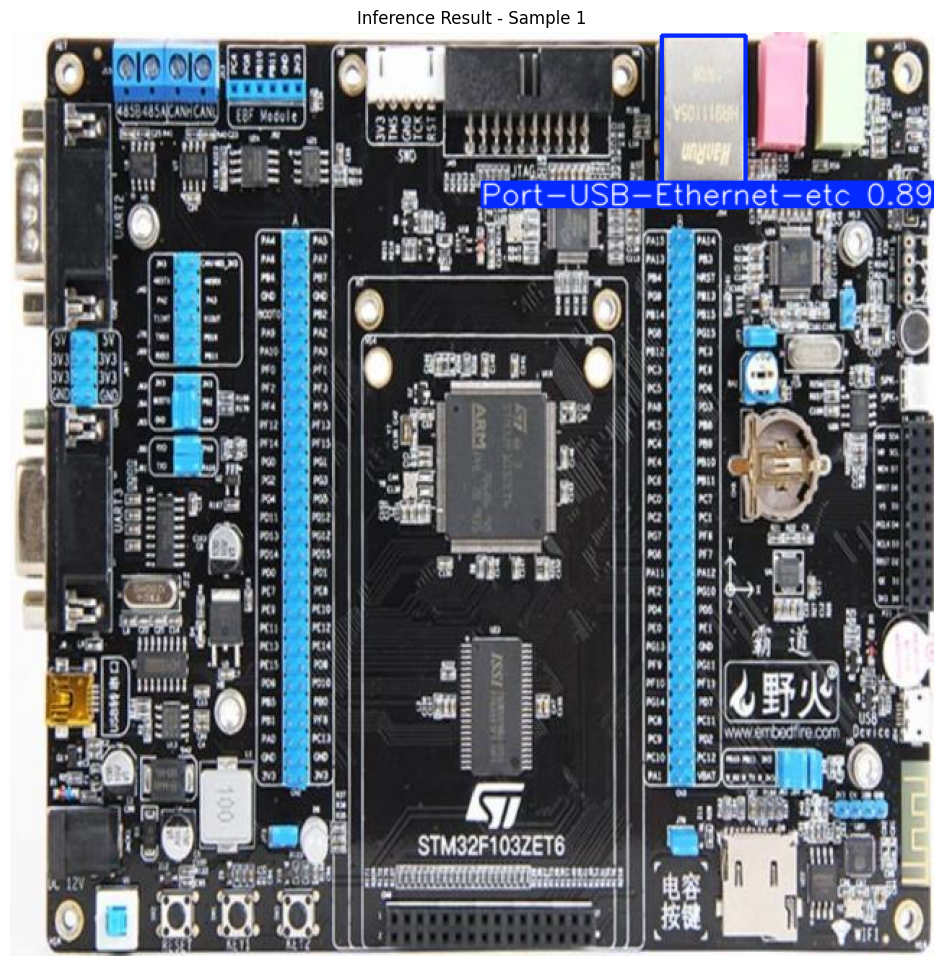

In [7]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Instantiate the model with your optimal trained weights
# (Path derived from your training output logs: train-3)
model = YOLO('runs/obb/train-3/weights/best.pt')

# 2. Define the path to your unseen test images
# (Update this if your test folder has a different name)
test_source = '/kaggle/input/datasets/seikhmustakim/port-pcb/pcb_port/test/images'

# 3. Execute inference
# save=True writes the annotated images to a new folder in /kaggle/working/runs/obb/predict
results = model.predict(
    source=test_source,
    save=True,       # Save predictions to disk
    conf=0.25,       # Confidence threshold (adjust to filter false positives/negatives)
    iou=0.45         # NMS IoU threshold for overlapping boxes
)

# 4. Programmatic Visualization (Optional)
# Extract the plotted image array from the first result object
if len(results) > 0:
    res_plot = results[0].plot()
    
    # Render the array using matplotlib (convert BGR to RGB for correct colors)
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Inference Result - Sample 1")
    plt.show()
else:
    print("No test images found or no predictions made.")

In [9]:

import ipywidgets as widgets
from IPython.display import display, clear_output
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load the optimized weights (update path if running a different training session)
model = YOLO('runs/obb/train-3/weights/best.pt')

# 2. Instantiate UI Widgets
uploader = widgets.FileUpload(
    accept='image/*', 
    multiple=False,
    description='Upload Image'
)
button = widgets.Button(
    description='Run Inference',
    button_style='success'
)
output = widgets.Output()

# Render the UI elements
display(uploader, button, output)

# 3. Define Callback function for execution
def process_image(b):
    with output:
        clear_output()
        if not uploader.value:
            print("❌ No image uploaded. Please upload an image first.")
            return
            
        print("Processing uploaded byte stream...")
        
        # Handle API differences between ipywidgets v7 and v8
        try:
            if isinstance(uploader.value, dict):
                # ipywidgets v7 format
                filename = list(uploader.value.keys())[0]
                content = uploader.value[filename]['content']
            else:
                # ipywidgets v8 format
                content = uploader.value[0]['content']
        except Exception as e:
            print(f"Error extracting upload data: {e}")
            return
            
        # Decode the binary stream directly into a NumPy array (BGR format)
        nparr = np.frombuffer(content, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        
        # Execute forward pass using the in-memory array
        results = model.predict(source=img, conf=0.25, iou=0.45)
        
        # Visualize the annotated tensor
        if len(results) > 0:
            res_plot = results[0].plot()
            
            plt.figure(figsize=(10, 10))
            plt.imshow(cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title("Custom Upload Inference Result")
            plt.show()
        else:
            print("Inference executed, but no objects were detected.")

# 4. Bind the execution logic to the button click event
button.on_click(process_image)

FileUpload(value=(), accept='image/*', description='Upload Image')

Button(button_style='success', description='Run Inference', style=ButtonStyle())

Output()